## Language Detection Notebook

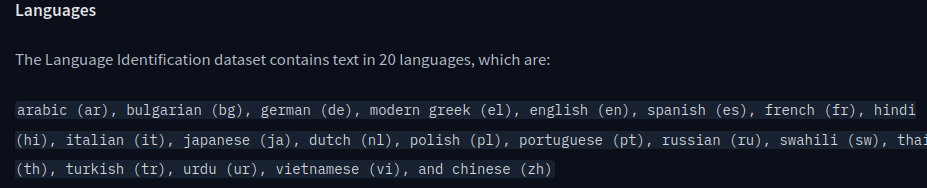

### Import Libraries

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

### Load Dataset

In [ ]:
import datasets

# You can find many datasets on the Hugging Face Hub: https://huggingface.co/datasets
dataset = datasets.load_dataset('papluca/language-identification')


In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})

### Read dataset and Explore data set

In [ ]:
train_dataset = dataset['train']
test_dataset = dataset['test']
validation_dataset = dataset['validation']

print("\n--- Train Dataset (first 5 examples) ---")
for i in range(5):
    print(train_dataset[i])

print("\n--- Test Dataset (first 5 examples) ---")
for i in range(5):
    print(test_dataset[i])

print("\n--- Validation Dataset (first 5 examples) ---")
for i in range(5):
    print(validation_dataset[i])


--- Train Dataset (first 5 examples) ---
{'labels': 'pt', 'text': 'os chefes de defesa da estónia, letónia, lituânia, alemanha, itália, espanha e eslováquia assinarão o acordo para fornecer pessoal e financiamento para o centro.'}
{'labels': 'bg', 'text': 'размерът на хоризонталната мрежа може да бъде по реда на няколко километра ( km ) за на симулация до около 100 km за на симулация .'}
{'labels': 'zh', 'text': '很好，以前从不去评价，不知道浪费了多少积分，现在知道积分可以换钱，就要好好评价了，后来我就把这段话复制走了，既能赚积分，还省事，走到哪复制到哪，最重要的是，不用认真的评论了，不用想还差多少字，直接发出就可以了，推荐给大家！！'}
{'labels': 'th', 'text': 'สำหรับ ของเก่า ที่ จริงจัง ลอง   honeychurch   ของเก่า ที่ ไม่   29   สำหรับ เฟอร์นิเจอร์ และ เงิน ไท ร้อง บริษัท ที่   122   สำหรับ ลาย คราม'}
{'labels': 'ru', 'text': 'Он увеличил давление .'}

--- Test Dataset (first 5 examples) ---
{'labels': 'nl', 'text': 'Een man zingt en speelt gitaar.'}
{'labels': 'nl', 'text': 'De technologisch geplaatste Nasdaq Composite Index .IXIC daalde met 25,36 punten, of 1,53 procent, tot 1.628,26.'}
{'la

### Check Data Impalance

In [ ]:
from collections import Counter

# Extract all labels from the training dataset
train_labels = [example['labels'] for example in train_dataset]

# Count the occurrences of each label
label_counts = Counter(train_labels)

print("\n--- Label Distribution in Train Dataset ---")
for label, count in sorted(label_counts.items()):
    print(f"{label}: {count}")


--- Label Distribution in Train Dataset ---
ar: 3500
bg: 3500
de: 3500
el: 3500
en: 3500
es: 3500
fr: 3500
hi: 3500
it: 3500
ja: 3500
nl: 3500
pl: 3500
pt: 3500
ru: 3500
sw: 3500
th: 3500
tr: 3500
ur: 3500
vi: 3500
zh: 3500


/tmp/ipykernel_6796/1048659939.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Language', y='Count', data=labels_df, palette='viridis')


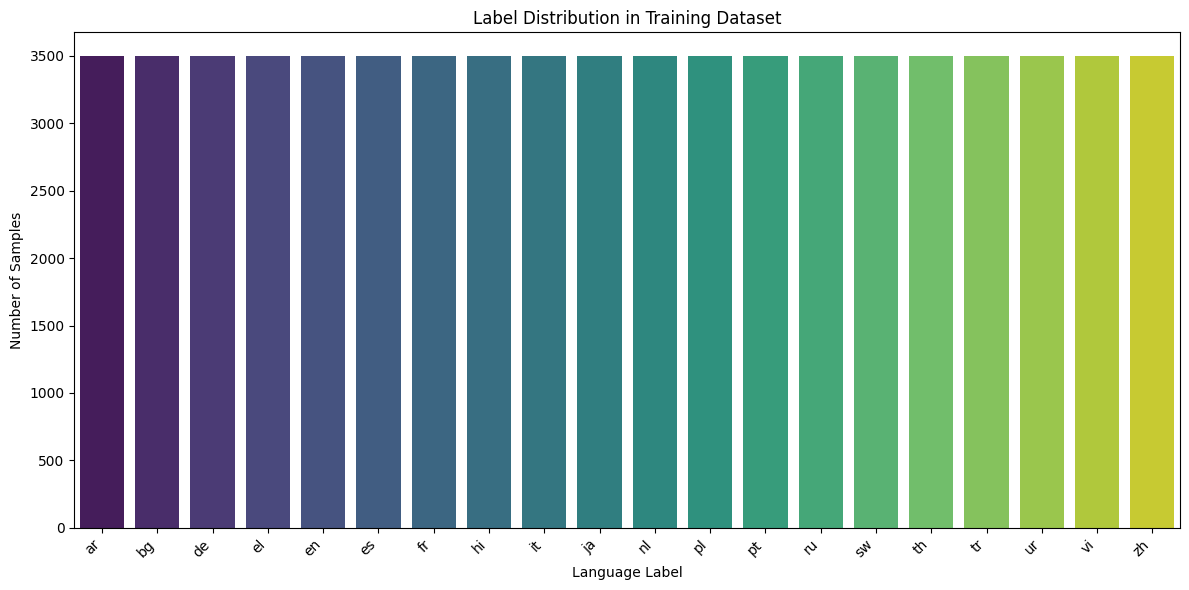

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert Counter to a DataFrame for easier plotting
labels_df = pd.DataFrame(label_counts.items(), columns=['Language', 'Count'])
labels_df = labels_df.sort_values('Language')

plt.figure(figsize=(12, 6))
sns.barplot(x='Language', y='Count', data=labels_df, palette='viridis')
plt.title('Label Distribution in Training Dataset')
plt.xlabel('Language Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Text Preprocessing

In [ ]:
!pip install fugashi konlpy pythainlp

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.8/19.8 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 30.1 MB/s eta 0:00:00


In [ ]:
import re
import unicodedata
import string

# ── Optional: install these before importing ──────────────────────────────────
# pip install jieba fugashi unidic-lite pythainlp
# ─────────────────────────────────────────────────────────────────────────────

# Script detection: map each language code to its Unicode block range
# We detect by sampling the dominant script in the text itself.

SCRIPT_RANGES = {
    "arabic":     (0x0600, 0x06FF),
    "devanagari": (0x0900, 0x097F),
    "cyrillic":   (0x0400, 0x04FF),
    "greek":      (0x0370, 0x03FF),
    "cjk":        (0x4E00, 0x9FFF),   # CJK Unified Ideographs
    "hiragana":   (0x3040, 0x309F),
    "katakana":   (0x30A0, 0x30FF),
    "hangul":     (0xAC00, 0xD7AF),
    "thai":       (0x0E00, 0x0E7F),
    "latin":      (0x0041, 0x024F),   # Basic Latin + Latin Extended
}

def detect_dominant_script(text: str) -> str:
    """
    Walk through the text and count characters per script block.
    Returns the name of the most common script.
    """
    counts = {script: 0 for script in SCRIPT_RANGES}
    for ch in text:
        cp = ord(ch)
        for script, (lo, hi) in SCRIPT_RANGES.items():
            if lo <= cp <= hi:
                counts[script] += 1
                break
    if max(counts.values()) == 0:
        return "latin"   # safe default
    return max(counts, key=counts.get)


def normalize_unicode(text: str, script: str) -> str:
    """
    Apply the right Unicode normalization form for each script.

    - NFC  : compose base + combining marks into a single code point.
              Best for Latin (French, German, Spanish…) and CJK.
    - NFKD : decompose + compatibility. Unifies variant Arabic letter
              forms (e.g. ﻻ → لا) and Persian/Urdu variants.
    """
    if script in ("arabic", "devanagari"):
        return unicodedata.normalize("NFKD", text)
    else:
        return unicodedata.normalize("NFC", text)


def remove_noise(text: str) -> str:
    """
    Strip elements that carry no language-identity signal:
      - URLs / email addresses
      - HTML tags
      - Digits (language-neutral)
      - Punctuation EXCEPT for characters that ARE language signals
        (e.g. Arabic ء or French guillemets — leave those via Unicode cat.)
    """
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)      # URLs
    text = re.sub(r"\S+@\S+\.\S+", " ", text)               # emails
    text = re.sub(r"<[^>]+>", " ", text)                    # HTML tags
    text = re.sub(r"\d+", " ", text)                        # numbers
    # Remove ASCII punctuation only (not Unicode punctuation like ¿ ¡ « »)
    text = re.sub(r"[!\"#$%&'()*+,\-./:;<=>?@\[\\\]^_`{|}~]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def segment_cjk(text: str, lang: str) -> str:
    """
    Insert explicit spaces between words in space-free CJK scripts.
    Falls back to raw text if the segmentation library is not installed.
    """
    if lang == "zh":
        try:
            import jieba
            return " ".join(jieba.cut(text))
        except ImportError:
            pass  # fall back to char-level — TF-IDF char_wb still works

    elif lang == "ja":
        try:
            import fugashi
            tagger = fugashi.Tagger()
            return " ".join(w.surface for w in tagger(text))
        except ImportError:
            pass

    elif lang == "ko":
        try:
            from konlpy.tag import Okt
            okt = Okt()
            return " ".join(okt.morphs(text))
        except ImportError:
            pass

    return text  # no segmenter installed: char n-grams will still work


def segment_thai(text: str) -> str:
    """Thai has no spaces between words — use pythainlp."""
    try:
        from pythainlp.tokenize import word_tokenize
        return " ".join(word_tokenize(text, engine="newmm"))
    except ImportError:
        return text


# ─── Language metadata ────────────────────────────────────────────────────────
# Maps each language code to its dominant script and whether to lowercase.
# Lowercase is meaningful for Latin/Greek/Cyrillic but irrelevant for
# Arabic, Devanagari, CJK, Thai.

LANG_META = {
    "ar": {"script": "arabic",     "lowercase": False},
    "bg": {"script": "cyrillic",   "lowercase": True },
    "de": {"script": "latin",      "lowercase": True },
    "el": {"script": "greek",      "lowercase": True },
    "en": {"script": "latin",      "lowercase": True },
    "es": {"script": "latin",      "lowercase": True },
    "fr": {"script": "latin",      "lowercase": True },
    "hi": {"script": "devanagari", "lowercase": False},
    "it": {"script": "latin",      "lowercase": True },
    "ja": {"script": "hiragana",   "lowercase": False},
    "nl": {"script": "latin",      "lowercase": True },
    "pl": {"script": "latin",      "lowercase": True },
    "pt": {"script": "latin",      "lowercase": True },
    "ru": {"script": "cyrillic",   "lowercase": True },
    "sw": {"script": "latin",      "lowercase": True },
    "th": {"script": "thai",       "lowercase": False},
    "tr": {"script": "latin",      "lowercase": True },
    "ur": {"script": "arabic",     "lowercase": False},
    "vi": {"script": "latin",      "lowercase": True },
    "zh": {"script": "cjk",        "lowercase": False},
}


def preprocess(text: str, lang: str = None) -> str:
    """
    Full preprocessing pipeline for a single text sample.

    Parameters
    ----------
    text : str
        Raw input text.
    lang : str or None
        Two-letter language code (e.g. 'fr', 'zh').
        If None, script is auto-detected from the text itself.
        Pass lang when you know it (training time) — skip it at inference time.

    Returns
    -------
    str
        Clean, normalized, ready-for-TF-IDF text.
    """
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ""

    # ── 1. Resolve script ─────────────────────────────────────────────────────
    if lang and lang in LANG_META:
        meta = LANG_META[lang]
        script = meta["script"]
        do_lower = meta["lowercase"]
    else:
        # Inference mode: detect from the text itself
        script = detect_dominant_script(text)
        do_lower = script in ("latin", "cyrillic", "greek")

    # ── 2. Unicode normalization ──────────────────────────────────────────────
    text = normalize_unicode(text, script)

    # ── 3. Lowercase (only where meaningful) ─────────────────────────────────
    if do_lower:
        text = text.lower()

    # ── 4. Remove noise ───────────────────────────────────────────────────────
    text = remove_noise(text)

    # ── 5. Script-specific segmentation ──────────────────────────────────────
    if lang == "zh" or script == "cjk":
        text = segment_cjk(text, lang or "zh")
    elif lang == "ja" or script == "hiragana":
        text = segment_cjk(text, "ja")
    elif lang == "ko" or script == "hangul":
        text = segment_cjk(text, "ko")
    elif lang == "th" or script == "thai":
        text = segment_thai(text)

    # ── 6. Final cleanup ─────────────────────────────────────────────────────
    text = re.sub(r"\s+", " ", text).strip()

    return text


# ─── Dataset-level helper (apply at training time) ───────────────────────────

def preprocess_dataset(texts, labels):
    """
    Apply preprocess() to every sample in the dataset.
    Pass the lang code so preprocessing is maximally precise.
    """
    return [preprocess(text, lang=lang) for text, lang in zip(texts, labels)]

### Prepare Data

In [ ]:
X_train = dataset["train"]["text"]
y_train = dataset["train"]["labels"]
X_val  = dataset["validation"]["text"]
y_val  = dataset["validation"]["labels"]


In [ ]:
len(X_train), len(y_train), len(X_val), len(y_val)

(70000, 70000, 10000, 10000)

In [ ]:
# Install unidic-lite for fugashi to find its dictionaries
!pip install unidic-lite

# 2. Preprocess — pass lang label so each text gets its optimal treatment
X_train_clean = preprocess_dataset(X_train, y_train)
X_test_clean  = preprocess_dataset(X_val,  y_val)

### Train initial model

In [ ]:
# 3. TF-IDF + Logistic Regression pipeline
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        analyzer="char_wb",      # word-boundary char n-grams
        ngram_range=(1, 4),      # 1 to 4-grams
        max_features=100_000,
        sublinear_tf=True,       # log scale TF
        strip_accents=None,      # CRITICAL: never strip diacritics
        min_df=2,
    )),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        C=5,
        max_iter=1000,
        n_jobs=-1,
    )),
])

pipeline.fit(X_train_clean, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb', max_features=100000,
                                 min_df=2, ngram_range=(1, 4),
                                 sublinear_tf=True)),
                ('clf',
                 LogisticRegression(C=5, max_iter=1000,
                                    multi_class='multinomial', n_jobs=-1))])

In [ ]:
# 4. Evaluate
preds = pipeline.predict(X_test_clean)
print(classification_report(y_test, preds))

# 5. Inference (no lang label available — auto-detects script)
def predict_language(raw_text: str) -> str:
    clean = preprocess(raw_text, lang=None)   # auto-detect mode
    return pipeline.predict([clean])[0]

print(predict_language("Bonjour, comment allez-vous?"))  # → 'fr'
print(predict_language("こんにちは世界"))

              precision    recall  f1-score   support

          ar       1.00      0.99      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       0.99      1.00      1.00       500
          es       1.00      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.95      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       0.99      1.00      0.99       500
          pl       1.00      1.00      1.00       500
          pt       1.00      1.00      1.00       500
          ru       1.00      1.00      1.00       500
          sw       0.94      1.00      0.97       500
          th       1.00      1.00      1.00       500
          tr       0.99      1.00      1.00       500
          ur       1.00    

In [ ]:
import datasets

# Define X_test and y_test from the actual test dataset
X_test = dataset["test"]["text"]
y_test = dataset["test"]["labels"]

# Preprocess the actual test dataset
X_test_clean_actual = preprocess_dataset(X_test, y_test)

# Predict on the actual cleaned test data
preds_actual = pipeline.predict(X_test_clean_actual)

# Print the classification report for the actual test set
print("\n--- Evaluation using the actual Test Set ---")
print(classification_report(y_test, preds_actual))


--- Evaluation using the actual Test Set ---
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       0.99      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       1.00      0.99      1.00       500
          pl       1.00      0.99      1.00       500
          pt       1.00      0.99      0.99       500
          ru       1.00      1.00      1.00       500
          sw       0.93      1.00      0.96       500
          th       1.00      1.00      1.00       500
          tr       1.00      1.00  